In [3]:
import os
import random
import warnings

import numpy as np
import matplotlib.pyplot as plt

import torch
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split, Dataset
warnings.filterwarnings("ignore")

random.seed(42)
torch.manual_seed(42)

In [4]:
EUROSAT_PATH = "../dataset/EuroSAT"

print("Dataset Exists:", os.path.exists(EUROSAT_PATH))

Dataset Exists: True


In [5]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [6]:
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [7]:
dataset = ImageFolder(EUROSAT_PATH)

print("Total Images:", len(dataset))
print("Classes:", len(dataset.classes))

Total Images: 27000
Classes: 10


In [8]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print("Training Images:", len(train_dataset))
print("Validation Images:", len(val_dataset))

Training Images: 21600
Validation Images: 5400


In [9]:
from torch.utils.data import Dataset

class TransformDataset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, index):
        image, label = self.subset[index]

        if self.transform:
            image = self.transform(image)

        return image, label

In [10]:
train_dataset = TransformDataset(train_dataset, train_transform)
val_dataset = TransformDataset(val_dataset, val_transform)

In [11]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

In [12]:
images, labels = next(iter(train_loader))

print("Images Shape :", images.shape)
print("Labels Shape :", labels.shape)

Images Shape : torch.Size([32, 3, 224, 224])
Labels Shape : torch.Size([32])


In [13]:
def imshow(img):
    img = img.numpy().transpose((1, 2, 0))

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = std * img + mean
    img = np.clip(img, 0, 1)

    plt.imshow(img)

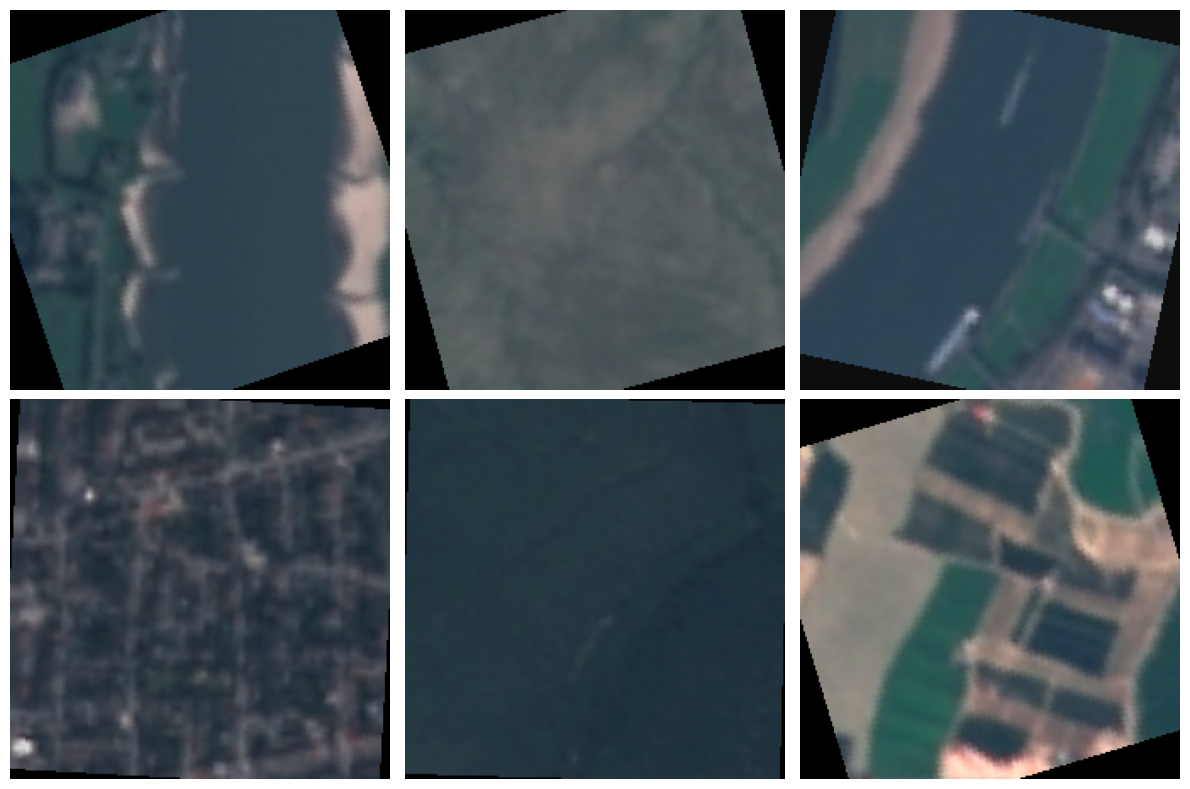

In [14]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 8))

for i in range(6):
    plt.subplot(2, 3, i + 1)
    imshow(images[i])
    plt.axis("off")

plt.tight_layout()
plt.show() 